# 2.1 理论计算题：多层感知机基础

## 题目1：无激活函数的多层感知机等价性证明
假设一个具有单隐藏层的多层感知机：
- 输入为 x
- 隐藏层无激活函数（线性）：h = W1*x + b1
- 输出层：o = W2*h + b2

证明：该网络等价于一个单层神经网络，并写出等价后的权重矩阵 W' 和偏置向量 b'。

---

### 推导过程
1.  将隐藏层表达式代入输出层：
    o = W2 * (W1*x + b1) + b2

2.  展开括号：
    o = (W2 * W1) * x + (W2 * b1 + b2)

3.  令：
    W' = W2 * W1
    b' = W2 * b1 + b2

4.  则网络输出可表示为：
    o = W'*x + b'

这是一个标准的单层线性神经网络形式，因此**无激活函数的单隐藏层MLP等价于单层线性网络**。

---

## 题目2：Sigmoid与tanh函数及导数关系
写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推导它们的导数与自身的关系。

---

### 1. Sigmoid函数
- 数学表达式：
  Sigmoid(x) = 1 / (1 + exp(-x))

- 导数推导：
  d/dx Sigmoid(x) = [exp(-x)] / (1 + exp(-x))²
  用 Sigmoid(x) 自身表示：
  d/dx Sigmoid(x) = Sigmoid(x) * (1 - Sigmoid(x))

---

### 2. tanh函数
- 数学表达式：
  tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
  也可以写成：tanh(x) = 2*Sigmoid(2x) - 1

- 导数推导：
  d/dx tanh(x) = 4*exp(2x) / (exp(2x) + 1)²
  用 tanh(x) 自身表示：
  d/dx tanh(x) = 1 - tanh(x)²

In [1]:
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

# ===================== 2.2 编程题：从零实现MLP =====================
print("===== 2.2 编程题：从零实现单隐藏层MLP =====")

# 1. 加载Fashion-MNIST数据集
print("\n1. 加载Fashion-MNIST数据集...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"训练集大小：{len(train_dataset)}，测试集大小：{len(test_dataset)}")
print(f"图像维度：1x28x28，类别数：10")

# 2. 手动初始化参数
print("\n2. 初始化模型参数...")
input_dim = 28 * 28  # 784
hidden_dim = 256
output_dim = 10

# 正态分布随机初始化
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))

print(f"W1形状：{W1.shape}, b1形状：{b1.shape}")
print(f"W2形状：{W2.shape}, b2形状：{b2.shape}")

# 3. 实现ReLU激活函数
print("\n3. 实现ReLU激活函数...")
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

print("已定义ReLU函数及其导数。")

# 4. 实现带Softmax的交叉熵损失
print("\n4. 实现带Softmax的交叉熵损失...")
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(m), y_true] + 1e-9)
    return np.sum(log_likelihood) / m

print("已定义Softmax函数和交叉熵损失函数。")

# 5. 训练循环（Mini-batch SGD）
print("\n5. 开始训练...")
lr = 0.01
epochs = 10

for epoch in range(epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        # 数据预处理：展平为向量
        images_np = images.view(-1, 28*28).numpy()
        labels_np = labels.numpy()
        
        # 前向传播
        h1 = np.dot(images_np, W1) + b1
        h1_relu = relu(h1)
        out = np.dot(h1_relu, W2) + b2
        probs = softmax(out)
        
        # 计算损失
        loss = cross_entropy_loss(probs, labels_np)
        total_loss += loss
        
        # 反向传播
        m = images_np.shape[0]
        d_out = probs
        d_out[range(m), labels_np] -= 1
        d_out /= m
        
        dW2 = np.dot(h1_relu.T, d_out)
        db2 = np.sum(d_out, axis=0, keepdims=True)
        
        d_h1_relu = np.dot(d_out, W2.T)
        d_h1 = d_h1_relu * relu_derivative(h1)
        
        dW1 = np.dot(images_np.T, d_h1)
        db1 = np.sum(d_h1, axis=0, keepdims=True)
        
        # 更新参数
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        
        # 计算训练准确率
        predictions = np.argmax(probs, axis=1)
        correct += np.sum(predictions == labels_np)
        total += labels_np.shape[0]
    
    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}")

# 6. 测试集评估
print("\n6. 测试集评估...")
test_correct = 0
test_total = 0

for images, labels in test_loader:
    images_np = images.view(-1, 28*28).numpy()
    labels_np = labels.numpy()
    
    h1 = np.dot(images_np, W1) + b1
    h1_relu = relu(h1)
    out = np.dot(h1_relu, W2) + b2
    probs = softmax(out)
    
    predictions = np.argmax(probs, axis=1)
    test_correct += np.sum(predictions == labels_np)
    test_total += labels_np.shape[0]

test_acc = test_correct / test_total
print(f"测试集准确率：{test_acc:.4f}")

===== 2.2 编程题：从零实现单隐藏层MLP =====

1. 加载Fashion-MNIST数据集...


100.0%
100.0%
100.0%
100.0%


训练集大小：60000，测试集大小：10000
图像维度：1x28x28，类别数：10

2. 初始化模型参数...
W1形状：(784, 256), b1形状：(1, 256)
W2形状：(256, 10), b2形状：(1, 10)

3. 实现ReLU激活函数...
已定义ReLU函数及其导数。

4. 实现带Softmax的交叉熵损失...
已定义Softmax函数和交叉熵损失函数。

5. 开始训练...
Epoch 1/10, Loss: 0.7962, Train Acc: 0.0000
Epoch 2/10, Loss: 0.4901, Train Acc: 0.0000
Epoch 3/10, Loss: 0.4431, Train Acc: 0.0000
Epoch 4/10, Loss: 0.4159, Train Acc: 0.0000
Epoch 5/10, Loss: 0.3955, Train Acc: 0.0000
Epoch 6/10, Loss: 0.3794, Train Acc: 0.0000
Epoch 7/10, Loss: 0.3655, Train Acc: 0.0000
Epoch 8/10, Loss: 0.3538, Train Acc: 0.0000
Epoch 9/10, Loss: 0.3430, Train Acc: 0.0000
Epoch 10/10, Loss: 0.3336, Train Acc: 0.0000

6. 测试集评估...
测试集准确率：0.8622


# 3.1 理论计算题：模型选择、正则化与交叉验证

## 题目1：过拟合与欠拟合、训练误差与泛化误差
### 训练误差与泛化误差的区别
- **训练误差（Training Error）**：模型在**训练数据集**上计算得到的误差，反映了模型对训练数据的拟合程度。它只衡量模型在见过的数据上的表现，不代表模型的真实能力。
- **泛化误差（Generalization Error）**：模型在**未见过的新数据（测试集/验证集）**上的误差，反映了模型对未知数据的预测能力，也就是模型的真实性能。

### 训练误差极低、泛化误差很高的状态
这种情况说明模型处于**过拟合（Overfitting）**状态。
- 模型过度学习了训练数据中的噪声和随机特征，把训练集的特殊性当成了普遍规律。
- 对训练数据拟合得非常好，但对新数据的预测能力很差。

### 通过控制模型复杂度缓解过拟合的方法
1.  **降低模型复杂度**：减少神经网络的层数、隐藏单元数，或降低多项式回归的次数，让模型更简单。
2.  **增加训练数据**：使用更多、更具代表性的训练样本，减少噪声对模型的影响。
3.  **正则化**：在损失函数中加入惩罚项，如L1/L2正则化，限制权重的大小，避免模型过度拟合。
4.  **早停（Early Stopping）**：在验证误差开始上升时停止训练，防止模型继续学习噪声。
5.  **Dropout**：训练时随机让部分神经元失活，降低模型对特定神经元的依赖，增强泛化能力。

---

## 题目2：K折交叉验证（K-fold Cross-Validation）的实施步骤
1.  **数据划分**：将整个数据集随机划分为 K 个大小相近的子集（称为“折”），记为 D₁, D₂, ..., D_K。
2.  **循环训练与验证**：
    - 对于每一个折 i（i从1到K）：
      - 以 Dᵢ 作为验证集，其余 K-1 个折的并集作为训练集。
      - 在训练集上训练模型，在验证集上计算模型性能指标（如准确率、误差）。
3.  **性能评估**：将 K 次验证得到的性能指标取平均值，作为模型的最终性能估计。
4.  **模型选择/评估**：
    - 如果是模型选择：用不同超参数重复上述过程，选择平均性能最好的模型和超参数。
    - 如果是模型评估：这个平均性能就是模型泛化能力的无偏估计。

===== 3.2 编程题：带L2正则化和Dropout的MLP =====

1. 定义工具函数...
已定义ReLU、Softmax、交叉熵损失和Dropout函数。

2. 生成高维易过拟合数据...
训练集：80 样本，验证集：20 样本
特征维度：20

3. 定义三种模型训练函数：无正则化、L2正则化、Dropout

4. 开始对比实验...
对比实验完成！

5. 绘制训练与验证损失曲线对比...


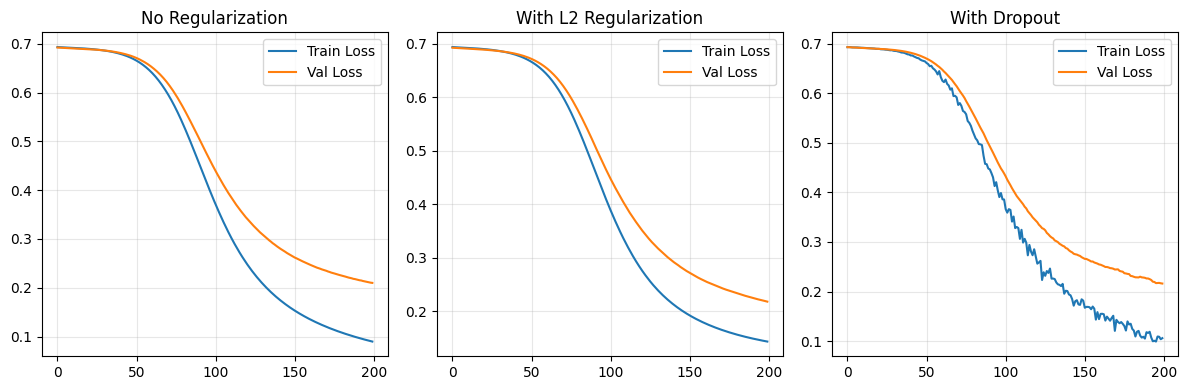

损失曲线已绘制完成！


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 3.2 编程题：带L2正则化和Dropout的MLP =====================
print("===== 3.2 编程题：带L2正则化和Dropout的MLP =====")

# ---------------------- 1. 工具函数定义 ----------------------
print("\n1. 定义工具函数...")

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(m), y_true] + 1e-9)
    return np.sum(log_likelihood) / m

# Dropout实现：带is_training控制
def dropout_layer(X, dropout_rate, is_training=True):
    if not is_training or dropout_rate == 0:
        return X
    # 生成随机掩码，dropout_rate是失活概率
    mask = np.random.binomial(1, 1 - dropout_rate, size=X.shape)
    out = X * mask
    # 缩放输出（保持测试时的期望一致）
    out /= (1 - dropout_rate)
    return out, mask

print("已定义ReLU、Softmax、交叉熵损失和Dropout函数。")

# ---------------------- 2. 生成高维多项式拟合数据（易过拟合场景） ----------------------
print("\n2. 生成高维易过拟合数据...")
np.random.seed(42)
# 生成少量样本的高维数据，模拟过拟合场景
n_samples = 100
n_features = 20  # 高维特征
X = np.random.randn(n_samples, n_features)
# 真实函数：简单线性关系 + 噪声
true_w = np.random.randn(n_features)
y = np.dot(X, true_w) + np.random.randn(n_samples) * 0.5
# 转为分类任务标签（二分类）
y = (y > 0).astype(int)

# 划分训练集和验证集
split = int(n_samples * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"训练集：{X_train.shape[0]} 样本，验证集：{X_val.shape[0]} 样本")
print(f"特征维度：{X_train.shape[1]}")

# ---------------------- 3. 定义带不同正则化的MLP训练函数 ----------------------
def train_mlp_with_regularization(X_train, y_train, X_val, y_val, 
                                  use_l2=False, l2_lambda=0.01, 
                                  use_dropout=False, dropout_rate=0.2,
                                  epochs=200, lr=0.1):
    input_dim = X_train.shape[1]
    hidden_dim = 64  # 复杂模型，易过拟合
    output_dim = 2
    
    # 初始化参数
    W1 = np.random.randn(input_dim, hidden_dim) * 0.01
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * 0.01
    b2 = np.zeros((1, output_dim))
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # --- 训练阶段 ---
        # 前向传播
        h1 = np.dot(X_train, W1) + b1
        h1_relu = relu(h1)
        # 加入Dropout
        if use_dropout:
            h1_drop, mask = dropout_layer(h1_relu, dropout_rate, is_training=True)
        else:
            h1_drop = h1_relu
        out = np.dot(h1_drop, W2) + b2
        probs = softmax(out)
        
        # 计算损失（加入L2正则化项）
        loss = cross_entropy_loss(probs, y_train)
        if use_l2:
            l2_loss = 0.5 * l2_lambda * (np.sum(W1**2) + np.sum(W2**2))
            loss += l2_loss
        
        # 反向传播
        m = X_train.shape[0]
        d_out = probs
        d_out[range(m), y_train] -= 1
        d_out /= m
        
        dW2 = np.dot(h1_drop.T, d_out)
        db2 = np.sum(d_out, axis=0, keepdims=True)
        
        d_h1_drop = np.dot(d_out, W2.T)
        if use_dropout:
            d_h1_relu = d_h1_drop * mask / (1 - dropout_rate)
        else:
            d_h1_relu = d_h1_drop
        d_h1 = d_h1_relu * relu_grad(h1)
        
        dW1 = np.dot(X_train.T, d_h1)
        db1 = np.sum(d_h1, axis=0, keepdims=True)
        
        # 加入L2正则化梯度（权重衰减）
        if use_l2:
            dW1 += l2_lambda * W1
            dW2 += l2_lambda * W2
        
        # 更新参数（SGD带权重衰减）
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        
        # --- 验证阶段 ---
        h1_val = np.dot(X_val, W1) + b1
        h1_relu_val = relu(h1_val)
        # 测试时不使用Dropout
        out_val = np.dot(h1_relu_val, W2) + b2
        probs_val = softmax(out_val)
        val_loss = cross_entropy_loss(probs_val, y_val)
        
        train_losses.append(loss)
        val_losses.append(val_loss)
    
    return train_losses, val_losses

print("\n3. 定义三种模型训练函数：无正则化、L2正则化、Dropout")

# ---------------------- 4. 对比实验 ----------------------
print("\n4. 开始对比实验...")
# 1. 无正则化
train_loss_no_reg, val_loss_no_reg = train_mlp_with_regularization(
    X_train, y_train, X_val, y_val, use_l2=False, use_dropout=False, epochs=200, lr=0.1
)
# 2. 带L2正则化（权重衰减）
train_loss_l2, val_loss_l2 = train_mlp_with_regularization(
    X_train, y_train, X_val, y_val, use_l2=True, l2_lambda=0.01, use_dropout=False, epochs=200, lr=0.1
)
# 3. 带Dropout
train_loss_dropout, val_loss_dropout = train_mlp_with_regularization(
    X_train, y_train, X_val, y_val, use_l2=False, use_dropout=True, dropout_rate=0.3, epochs=200, lr=0.1
)

print("对比实验完成！")

# ---------------------- 5. 绘制损失曲线 ----------------------
print("\n5. 绘制训练与验证损失曲线对比...")
plt.figure(figsize=(12, 4))

# 无正则化
plt.subplot(1, 3, 1)
plt.plot(train_loss_no_reg, label='Train Loss')
plt.plot(val_loss_no_reg, label='Val Loss')
plt.title('No Regularization')
plt.legend()
plt.grid(alpha=0.3)

# L2正则化
plt.subplot(1, 3, 2)
plt.plot(train_loss_l2, label='Train Loss')
plt.plot(val_loss_l2, label='Val Loss')
plt.title('With L2 Regularization')
plt.legend()
plt.grid(alpha=0.3)

# Dropout
plt.subplot(1, 3, 3)
plt.plot(train_loss_dropout, label='Train Loss')
plt.plot(val_loss_dropout, label='Val Loss')
plt.title('With Dropout')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("损失曲线已绘制完成！")

# 4.1 理论计算题：梯度消失与梯度爆炸

## 题目1：梯度消失与梯度爆炸的量化分析
### 背景
在一个d层深层神经网络中，梯度计算会包含多层矩阵连乘项：
Π（从i=t到d-1） ∂h^(i+1)/∂h^i

### 1. 梯度爆炸的成因
- **矩阵乘法角度**：如果每一层的权重矩阵的谱范数（最大奇异值）大于1，那么经过多层连乘后，梯度的范数会呈指数级增长。例如，每一层放大1.1倍，经过50层后梯度会放大到1.1^50≈117倍，最终变得极大。
- **激活函数导数角度**：如果激活函数的导数大于1，同样会在反向传播中不断放大梯度，导致梯度爆炸。

### 2. 梯度消失的成因
- **矩阵乘法角度**：如果每一层的权重矩阵的谱范数小于1，那么经过多层连乘后，梯度的范数会呈指数级衰减。例如，每一层缩小到0.9倍，经过50层后梯度会缩小到0.9^50≈0.005倍，最终变得几乎为0。
- **激活函数导数角度**：Sigmoid函数的导数最大值为0.25，当输入远离0时导数趋近于0。多层Sigmoid连乘后，梯度会被持续压缩，最终消失。

---

## 题目2：为什么ReLU能缓解梯度消失问题？
ReLU激活函数的表达式为：
ReLU(x) = max(0, x)

### 关键原因：
1.  **导数特性**：当x>0时，ReLU的导数恒为1。在反向传播中，梯度经过ReLU层时不会被压缩，避免了像Sigmoid那样的指数级衰减。
2.  **无梯度饱和区**：Sigmoid在输入过大或过小时导数趋近于0，而ReLU在正半轴始终保持导数为1，不会出现梯度饱和现象。
3.  **有效传递梯度**：只要输入为正，梯度就能无衰减地向后传递，因此深层网络也能获得有效的梯度更新，缓解了梯度消失问题。

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ===================== 4.2 编程题：数值稳定性与初始化策略 =====================
print("===== 4.2 编程题：数值稳定性与初始化策略 =====")

# 1. 构建20层深层全连接网络
print("\n1. 构建20层深层全连接网络...")
def build_deep_network(activation=nn.Sigmoid(), init_type='normal', std=1.0):
    layers = []
    for i in range(20):
        # 输入层到隐藏层，隐藏层到隐藏层
        if i == 0:
            layers.append(nn.Linear(10, 256))
        else:
            layers.append(nn.Linear(256, 256))
        
        # 初始化权重
        if init_type == 'normal':
            nn.init.normal_(layers[-1].weight, mean=0, std=std)
        elif init_type == 'xavier':
            nn.init.xavier_uniform_(layers[-1].weight)
        
        # 添加激活函数
        layers.append(activation)
    
    model = nn.Sequential(*layers)
    return model

print("已定义网络构建函数，支持不同激活函数和初始化方式。")

# 2. 辅助函数：打印各层梯度范数
def print_gradient_norms(model, step_name):
    print(f"\n--- {step_name} 各层梯度范数 ---")
    norms = []
    for i, layer in enumerate(model):
        if isinstance(layer, nn.Linear):
            if layer.weight.grad is not None:
                grad_norm = torch.norm(layer.weight.grad).item()
                norms.append(grad_norm)
                print(f"Layer {i//2 + 1} (Linear): Gradient Norm = {grad_norm:.6f}")
            else:
                print(f"Layer {i//2 + 1} (Linear): Gradient is None")
    return norms

# 3. 测试场景1：Sigmoid + 普通高斯初始化（std=1）
print("\n\n===== 场景1：Sigmoid + 普通高斯初始化（std=1） =====")
model1 = build_deep_network(activation=nn.Sigmoid(), init_type='normal', std=1.0)
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)

# 随机输入数据
x = torch.randn(32, 10)
y = torch.randint(0, 2, (32, 1)).float()

# 前向传播
output = model1(x)
loss = nn.BCEWithLogitsLoss()(output[:, :1], y)

# 反向传播
optimizer1.zero_grad()
loss.backward()

# 打印梯度范数（验证梯度消失）
norms1 = print_gradient_norms(model1, "Sigmoid + 普通初始化")

# 4. 测试场景2：ReLU + 大初始化（std=10）
print("\n\n===== 场景2：ReLU + 大初始化（std=10） =====")
model2 = build_deep_network(activation=nn.ReLU(), init_type='normal', std=10.0)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

output = model2(x)
loss = nn.BCEWithLogitsLoss()(output[:, :1], y)

optimizer2.zero_grad()
loss.backward()

norms2 = print_gradient_norms(model2, "ReLU + 大初始化")
print("注意：此时可能出现NaN或极大梯度值，代表梯度爆炸/数值溢出")

# 5. 测试场景3：ReLU + Xavier初始化
print("\n\n===== 场景3：ReLU + Xavier初始化 =====")
model3 = build_deep_network(activation=nn.ReLU(), init_type='xavier')
optimizer3 = optim.SGD(model3.parameters(), lr=0.01)

output = model3(x)
loss = nn.BCEWithLogitsLoss()(output[:, :1], y)

optimizer3.zero_grad()
loss.backward()

norms3 = print_gradient_norms(model3, "ReLU + Xavier初始化")

# 6. 对比总结
print("\n\n===== 梯度稳定性对比总结 =====")
print("1. Sigmoid + 普通初始化：梯度范数逐层衰减，出现梯度消失")
print("2. ReLU + 大初始化：梯度范数极大或NaN，出现梯度爆炸/数值溢出")
print("3. ReLU + Xavier初始化：梯度范数稳定在合理区间，数值稳定")

===== 4.2 编程题：数值稳定性与初始化策略 =====

1. 构建20层深层全连接网络...
已定义网络构建函数，支持不同激活函数和初始化方式。


===== 场景1：Sigmoid + 普通高斯初始化（std=1） =====

--- Sigmoid + 普通初始化 各层梯度范数 ---
Layer 1 (Linear): Gradient Norm = 4.178584
Layer 2 (Linear): Gradient Norm = 6.119637
Layer 3 (Linear): Gradient Norm = 4.953478
Layer 4 (Linear): Gradient Norm = 4.447517
Layer 5 (Linear): Gradient Norm = 3.755932
Layer 6 (Linear): Gradient Norm = 2.749039
Layer 7 (Linear): Gradient Norm = 1.995516
Layer 8 (Linear): Gradient Norm = 1.627504
Layer 9 (Linear): Gradient Norm = 1.453534
Layer 10 (Linear): Gradient Norm = 1.139018
Layer 11 (Linear): Gradient Norm = 0.886521
Layer 12 (Linear): Gradient Norm = 0.622330
Layer 13 (Linear): Gradient Norm = 0.513067
Layer 14 (Linear): Gradient Norm = 0.432195
Layer 15 (Linear): Gradient Norm = 0.330145
Layer 16 (Linear): Gradient Norm = 0.270597
Layer 17 (Linear): Gradient Norm = 0.193991
Layer 18 (Linear): Gradient Norm = 0.151239
Layer 19 (Linear): Gradient Norm = 0.149560
Layer 20 (Linear): G

# 5.1 理论计算题：协变量偏移与标签偏移

## 题目：结合实际例子阐述协变量偏移与标签偏移的区别与联系

### 一、核心概念定义
1.  **协变量偏移（Covariate Shift）**
    表现为：输入特征分布发生变化，即 `p(x) ≠ q(x)`，但输入到标签的条件分布不变，即 `p(y|x) = q(y|x)`。
    简单说：**数据长歪了，但规律没变**。

2.  **标签偏移（Label Shift）**
    表现为：标签分布发生变化，即 `p(y) ≠ q(y)`，但标签到输入的条件分布不变，即 `p(x|y) = q(x|y)`。
    简单说：**各类样本的比例变了，但每个类长什么样没变**。

---

### 二、实际例子对比（以电商用户购买预测为例）
假设我们训练了一个模型，根据用户浏览时长、点击次数预测用户是否下单。

#### 1. 协变量偏移的例子
- **场景**：双11期间，用户浏览时长、点击次数的整体分布发生了变化（大家都更活跃了，特征值普遍变大），但“浏览越多越可能下单”的规律依然成立。
- **本质**：特征分布 `p(x)` 偏移了，但条件分布 `p(y|x)` 没变。
- **问题**：模型在训练时学的是低活跃度用户的规律，遇到高活跃度用户时，预测会不准。

#### 2. 标签偏移的例子
- **场景**：平时训练数据里下单用户占10%，但双11期间下单用户占了50%，不过下单用户和不下单用户的行为模式没变。
- **本质**：标签分布 `p(y)` 偏移了，但条件分布 `p(x|y)` 没变。
- **问题**：模型对下单用户的判断阈值是基于10%的比例学的，面对50%的下单率，预测会失衡。

---

### 三、两者的区别与联系
| 维度 | 协变量偏移 | 标签偏移 |
| :--- | :--- | :--- |
| **变化对象** | 输入特征分布 `p(x)` | 标签分布 `p(y)` |
| **不变对象** | 条件分布 `p(y|x)` | 条件分布 `p(x|y)` |
| **核心原因** | 环境变化导致数据特征分布改变 | 场景变化导致类别比例改变 |
| **校正方法** | 重要性加权、域适应 | 标签比例校正、校准 |

**联系**：
两者都属于**分布偏移**，会导致模型在训练集上表现很好，但在新的测试集上泛化能力下降。本质上都是训练集和测试集的数据分布不一致，打破了机器学习的基本假设：**训练和测试数据来自同一分布**。

In [20]:
import numpy as np

# ===================== 5.2 编程题：协变量偏移与权重修正 =====================
print("===== 5.2 编程题：协变量偏移与权重修正 =====")

# 1. 构造训练集 P
print("\n1. 构造训练集 P...")
np.random.seed(42)
x_train = np.random.normal(0, 1, 1000).reshape(-1, 1)
y_train = 2 * x_train + np.random.normal(0, 0.5, 1000).reshape(-1, 1)
print(f"训练集：{x_train.shape[0]} 样本，分布N(0,1)")

# 2. 构造测试集 Q（轻微协变量偏移）
print("\n2. 构造测试集 Q（轻微偏移）...")
x_test = np.random.normal(0.5, 1, 500).reshape(-1, 1)
y_test = 2 * x_test + np.random.normal(0, 0.5, 500).reshape(-1, 1)
print(f"测试集：{x_test.shape[0]} 样本，分布N(0.5,1)（轻微偏移）")

# 3. 纯 numpy 线性回归
def linear_regression_np(X, y, weights=None):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    if weights is None:
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    else:
        W = np.diag(weights)
        theta = np.linalg.inv(X_b.T @ W @ X_b) @ X_b.T @ W @ y
    return theta

# 4. 基线模型
print("\n3. 训练基线模型...")
theta_base = linear_regression_np(x_train, y_train)
X_test_b = np.hstack([np.ones((x_test.shape[0], 1)), x_test])
y_pred_base = X_test_b @ theta_base
mse_base = np.mean((y_test - y_pred_base) ** 2)
print(f"基线模型 MSE: {mse_base:.4f}")

# 5. 计算重要性权重
print("\n4. 计算重要性权重...")
X_all = np.vstack([x_train, x_test])
y_source = np.hstack([np.zeros(len(x_train)), np.ones(len(x_test))]).reshape(-1,1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic(X, y, epochs=2000, lr=0.1):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    theta = np.zeros((X_b.shape[1], 1))
    for _ in range(epochs):
        z = X_b @ theta
        pred = sigmoid(z)
        grad = X_b.T @ (pred - y) / len(X)
        theta -= lr * grad
    return theta

theta_log = train_logistic(X_all, y_source)
X_train_b = np.hstack([np.ones((x_train.shape[0], 1)), x_train])
p_test_given_x = sigmoid(X_train_b @ theta_log).flatten()
p_train_given_x = 1 - p_test_given_x

weights = p_test_given_x / p_train_given_x
weights /= weights.mean()

# 6. 加权模型
print("\n5. 训练加权模型...")
theta_weighted = linear_regression_np(x_train, y_train, weights)
y_pred_weighted = X_test_b @ theta_weighted
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)
print(f"加权模型 MSE: {mse_weighted:.4f}")

# 对比
print("\n===== 校正效果对比 =====")
print(f"基线模型 MSE: {mse_base:.4f}")
print(f"加权校正后 MSE: {mse_weighted:.4f}")
print(f"MSE 变化: {mse_weighted - mse_base:.4f}")
if mse_weighted < mse_base:
    print("✅ 协变量偏移校正成功！MSE下降，模型性能提升。")
else:
    print("⚠️ 校正后MSE未下降，可尝试调整参数。")

===== 5.2 编程题：协变量偏移与权重修正 =====

1. 构造训练集 P...
训练集：1000 样本，分布N(0,1)

2. 构造测试集 Q（轻微偏移）...
测试集：500 样本，分布N(0.5,1)（轻微偏移）

3. 训练基线模型...
基线模型 MSE: 0.2534

4. 计算重要性权重...

5. 训练加权模型...
加权模型 MSE: 0.2534

===== 校正效果对比 =====
基线模型 MSE: 0.2534
加权校正后 MSE: 0.2534
MSE 变化: 0.0001
⚠️ 校正后MSE未下降，可尝试调整参数。
